# Comprehensive Guide to Pandas `read_excel()`
### Instructor Notes for Teaching — Beginner to Advanced
**Prodigy Training Hub**

---

## Learning Objectives

By the end of this notebook, students will be able to:

1. Read Excel files into Pandas using `pd.read_excel()` with full confidence
2. Navigate multiple sheets in a single workbook
3. Handle messy Excel files — skip title rows, set headers, handle bad formatting
4. Select only the columns and rows they need
5. Handle missing values, wrong data types, and dirty data properly
6. Combine data from multiple sheets into one DataFrame
7. Clean and transform real-world Excel data end-to-end

---

## The Dataset — `sample.xlsx`

This workbook has **four sheets**, each representing a real-world scenario:

| Sheet | Rows | Description |
|---|---|---|
| **Sales** | 320 | Product sales orders — has missing values, dirty data, duplicates |
| **Finance** | 215 | Departmental expense transactions — has missing values, duplicates |
| **Health** | 265 | Hospital patient records — has missing values, outlier ages, dirty BP values |
| **Inventory** | 100 | Stock items — first 3 rows are title rows (tests `skiprows`) |

Every sheet was designed with real cleaning challenges so students practise on authentic data.

---

> **How to use this notebook:** Read every markdown cell fully before running the code below it. Every parameter and line is explained. Run cells top to bottom — later sections depend on earlier ones.

---

---
# SECTION 0: Setup — Imports and Environment

---

Before we do anything, we import the libraries we need.

- **pandas** (`pd`) — our data analysis engine
- **numpy** (`np`) — numerical operations
- **matplotlib** (`plt`) — plotting and visualisation
- **warnings** — suppress minor version warnings that clutter output

We also configure pandas display options so that DataFrames are displayed neatly in the notebook.

In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 0.1 — Import Libraries and Configure Display
# ─────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')       # suppress minor warnings
%matplotlib inline

# Display options — show more columns and rows without truncation
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:,.2f}'.format)

print("Pandas version  :", pd.__version__)
print("NumPy version   :", np.__version__)
print("All libraries loaded successfully!")

Pandas version  : 2.3.1
NumPy version   : 2.3.1
All libraries loaded successfully!


In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 0.2 — Confirm the Excel File Exists and List Its Sheets
# ─────────────────────────────────────────────────────────────────

# Before reading, always confirm the file is accessible and check what sheets it has.
# ExcelFile gives us a preview without loading any data yet.

xl_file = pd.ExcelFile('sample.xlsx')

print("Workbook: sample.xlsx")
print("Number of sheets:", len(xl_file.sheet_names))
print()
print("Sheet names:")
for i, name in enumerate(xl_file.sheet_names):
    print(f"  [{i}] {name}")

Workbook: sample.xlsx
Number of sheets: 4

Sheet names:
  [0] Sales
  [1] Finance
  [2] Health
  [3] Inventory


---
# SECTION 1: Basic Usage of `pd.read_excel()`

---

## 1.1 The Syntax

```python
pd.read_excel(io, sheet_name=0, header=0, index_col=None,
              usecols=None, dtype=None, na_values=None,
              skiprows=None, nrows=None, parse_dates=False, ...)
```

The most important parameters:

| Parameter | Default | What it controls |
|---|---|---|
| `io` | — | File path, URL, or file-like object |
| `sheet_name` | `0` | Which sheet(s) to read (index, name, list, or `None` for all) |
| `header` | `0` | Row number to use as column names |
| `index_col` | `None` | Column to use as row index |
| `usecols` | `None` | Which columns to load |
| `dtype` | `None` | Force specific data types |
| `na_values` | — | Additional strings to treat as NaN |
| `skiprows` | `None` | Rows to skip at the top of the file |
| `nrows` | `None` | Maximum number of rows to read |
| `parse_dates` | `False` | Columns to parse as datetime |

---

## 1.2 Reading the First Sheet (Default Behaviour)

By default, `pd.read_excel()` reads the **first sheet** (index 0).

In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 1.1 — Read the First Sheet (Default)
# ─────────────────────────────────────────────────────────────────

# sheet_name=0 is the default — reads the first sheet (Sales)
df = pd.read_excel('sample.xlsx')

print("Sheet loaded: Sales (default — first sheet)")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print()
print("=== First 5 rows ===")
print(df.head())

Sheet loaded: Sales (default — first sheet)
Shape: 320 rows x 13 columns

=== First 5 rows ===
   OrderID   OrderDate     Customer Region       SalesRep      Channel Product  Quantity  UnitPrice Discount_Pct  \
0  ORD1000  2024-01-05  Customer_42  South  Tunde Adeyemi  Phone Order  Laptop         3 309,402.74            0   
1  ORD1001  2024-01-06  Customer_11  South  Tunde Adeyemi      Partner  Tablet         5 127,500.91           10   
2  ORD1002  2024-01-08  Customer_42  North     Ngozi Dike      Walk-in  Laptop         4        NaN            5   
3  ORD1003  2024-01-09  Customer_57   East    Aisha Garba       Online   Phone         3  76,285.93           20   
4  ORD1004  2024-01-11  Customer_77  South     Ngozi Dike      Walk-in  Laptop         2 397,280.17           15   

   TotalAmount     Status  Rating  
0   928,208.22  Delivered    5.00  
1   573,754.10  Delivered    2.00  
2 1,486,388.51   Returned    1.00  
3   183,086.23  Delivered    1.00  
4   675,376.29   Returned   

In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 1.2 — Quick Data Audit After Loading
# ─────────────────────────────────────────────────────────────────

# Always run these three commands immediately after loading any dataset.

# 1. info() — column names, types, and non-null counts
print("=== df.info() ===")
df.info()
print()

# 2. describe() — statistical summary of numeric columns
print("=== df.describe() ===")
print(df.describe())

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OrderID       320 non-null    object 
 1   OrderDate     320 non-null    object 
 2   Customer      311 non-null    object 
 3   Region        320 non-null    object 
 4   SalesRep      302 non-null    object 
 5   Channel       320 non-null    object 
 6   Product       320 non-null    object 
 7   Quantity      320 non-null    int64  
 8   UnitPrice     306 non-null    float64
 9   Discount_Pct  320 non-null    object 
 10  TotalAmount   310 non-null    float64
 11  Status        320 non-null    object 
 12  Rating        283 non-null    float64
dtypes: float64(3), int64(1), object(9)
memory usage: 32.6+ KB

=== df.describe() ===
       Quantity  UnitPrice  TotalAmount  Rating
count    320.00     306.00       310.00  283.00
mean       2.60 118,812.25   286,295.28    3.14
st

In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 1.3 — Check Missing Values Immediately
# ─────────────────────────────────────────────────────────────────

# isnull().sum() counts missing (NaN) values per column.
# This is the FIRST thing you check on any real dataset.

print("=== Missing Values Per Column ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

audit = pd.DataFrame({
    'Missing Count'  : missing,
    'Missing %'      : missing_pct
})
print(audit[audit['Missing Count'] > 0])
print()
print(f"Total missing cells: {df.isnull().sum().sum()}")

=== Missing Values Per Column ===
             Missing Count  Missing %
Customer                 9       2.80
SalesRep                18       5.60
UnitPrice               14       4.40
TotalAmount             10       3.10
Rating                  37      11.60

Total missing cells: 88


---
# SECTION 2: Reading Specific Sheets

---

## 2.1 By Sheet Name or Index

You specify which sheet to read using the `sheet_name` parameter:

| Value | Result |
|---|---|
| `0` | First sheet (default) |
| `1` | Second sheet |
| `'Sales'` | Sheet named "Sales" |
| `['Sales','Finance']` | List of specific sheets → returns a dict |
| `None` | All sheets → returns a dict |

In [6]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.1 — Read by Sheet Name
# ─────────────────────────────────────────────────────────────────

# By name — most readable and safest approach
df_finance = pd.read_excel('sample.xlsx', sheet_name='Finance')

print("=== Finance Sheet ===")
print(f"Shape: {df_finance.shape}")
print()
print(df_finance.head(6))

=== Finance Sheet ===
Shape: (215, 10)

  TransactionID TransactionDate Department  ExpenseType     Amount Currency ApprovedBy Approved BudgetCode Quarter
0      TXN02000      2024-01-01  Marketing     Supplies 318,717.72      GBP        CEO      NaN     BC-815      Q1
1      TXN02001      2024-01-02        NaN     Supplies 181,407.54      GBP        CFO      Yes     BC-827      Q1
2      TXN02002      2024-01-04         HR     Supplies 314,868.73      NGN        CEO      Yes     BC-573      Q1
3      TXN02003      2024-01-06  Marketing       Salary 126,671.82      NGN    Manager      Yes     BC-688      Q1
4      TXN02004      2024-01-08         IT  Maintenance 374,741.73      USD    Manager      Yes     BC-145      Q1
5      TXN02005      2024-01-10      Admin  Consultancy  49,350.85      NGN        HOD      Yes     BC-496      Q1


In [7]:
# ─────────────────────────────────────────────────────────────────
# CELL 2.2 — Read by Sheet Index Number
# ─────────────────────────────────────────────────────────────────

# By index — useful when sheet names are unknown or may change
# Index 0=Sales, 1=Finance, 2=Health, 3=Inventory

df_health = pd.read_excel('sample.xlsx', sheet_name=2)

print("=== Health Sheet (by index=2) ===")
print(f"Shape: {df_health.shape}")
print()
print(df_health.head(6))

=== Health Sheet (by index=2) ===
Shape: (265, 13)

  PatientID AdmissionDate DischargeDate     Hospital       Ward  PatientAge  Gender     Diagnosis  BP_Systolic  \
0  PAT03000    2024-01-01    2024-01-04    FMC Abuja        ICU      999.00    Male      Diabetes          NaN   
1  PAT03001    2024-01-02    2024-01-18    FMC Abuja   Surgical       29.00    Male       Anaemia       163.00   
2  PAT03002    2024-01-03    2024-01-17    FMC Abuja   Surgical       22.00    Male  Hypertension       123.00   
3  PAT03003    2024-01-05    2024-01-07   UNTH Enugu  Maternity       57.00    Male      Fracture       125.00   
4  PAT03004    2024-01-06    2024-01-09   LUTH Lagos        ICU       22.00  Female      COVID-19       160.00   
5  PAT03005    2024-01-08    2024-02-01  ABUTH Zaria        ICU       47.00    Male       Anaemia       119.00   

  BP_Diastolic  LengthOfStay     Outcome InsuranceType  
0          101             3    Referred       Private  
1           87            16    Ref

---
# SECTION 3: Reading Multiple Sheets at Once

---

## 3.1 `sheet_name=None` — Load All Sheets

When `sheet_name=None`, Pandas reads **every sheet** and returns a **Python dictionary** where:
- **Keys** = sheet names (strings)
- **Values** = DataFrames

This is extremely useful for workbooks with many related sheets.

In [8]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.1 — Load All Sheets at Once
# ─────────────────────────────────────────────────────────────────

# sheet_name=None returns an OrderedDict of {sheet_name: DataFrame}
all_sheets = pd.read_excel('sample.xlsx', sheet_name=None)

print("Return type:", type(all_sheets))
print()
print("=== Sheets available ===")
for name, df_sheet in all_sheets.items():
    print(f"  '{name}' — {df_sheet.shape[0]} rows x {df_sheet.shape[1]} cols")

Return type: <class 'dict'>

=== Sheets available ===
  'Sales' — 320 rows x 13 cols
  'Finance' — 215 rows x 10 cols
  'Health' — 265 rows x 13 cols
  'Inventory' — 103 rows x 10 cols


In [9]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.2 — Access Individual Sheets from the Dictionary
# ─────────────────────────────────────────────────────────────────

# Access any sheet by its name key
sales_df   = all_sheets['Sales']
finance_df = all_sheets['Finance']
health_df  = all_sheets['Health']

print("=== Sales (first 3 rows) ===")
print(sales_df.head(3))
print()
print("=== Finance (first 3 rows) ===")
print(finance_df.head(3))

=== Sales (first 3 rows) ===
   OrderID   OrderDate     Customer Region       SalesRep      Channel Product  Quantity  UnitPrice Discount_Pct  \
0  ORD1000  2024-01-05  Customer_42  South  Tunde Adeyemi  Phone Order  Laptop         3 309,402.74            0   
1  ORD1001  2024-01-06  Customer_11  South  Tunde Adeyemi      Partner  Tablet         5 127,500.91           10   
2  ORD1002  2024-01-08  Customer_42  North     Ngozi Dike      Walk-in  Laptop         4        NaN            5   

   TotalAmount     Status  Rating  
0   928,208.22  Delivered    5.00  
1   573,754.10  Delivered    2.00  
2 1,486,388.51   Returned    1.00  

=== Finance (first 3 rows) ===
  TransactionID TransactionDate Department ExpenseType     Amount Currency ApprovedBy Approved BudgetCode Quarter
0      TXN02000      2024-01-01  Marketing    Supplies 318,717.72      GBP        CEO      NaN     BC-815      Q1
1      TXN02001      2024-01-02        NaN    Supplies 181,407.54      GBP        CFO      Yes     BC-

In [10]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.3 — Load a Specific List of Sheets
# ─────────────────────────────────────────────────────────────────

# Pass a list of sheet names to load only those sheets
subset_sheets = pd.read_excel('sample.xlsx', sheet_name=['Sales', 'Finance'])

print("Loaded sheets:", list(subset_sheets.keys()))
print()
print("Sales shape  :", subset_sheets['Sales'].shape)
print("Finance shape:", subset_sheets['Finance'].shape)

Loaded sheets: ['Sales', 'Finance']

Sales shape  : (320, 13)
Finance shape: (215, 10)


In [11]:
# ─────────────────────────────────────────────────────────────────
# CELL 3.4 — Combining Multiple Sheets into One DataFrame
# ─────────────────────────────────────────────────────────────────

# pd.concat() stacks DataFrames vertically (adds rows).
# ignore_index=True resets the row index from 0 after combining.
# This only makes sense when sheets share the same column structure.

# Combine Sales + Finance sheets (they have different columns,
# so we add a 'source_sheet' column for traceability first)

sales_tagged   = all_sheets['Sales'].copy()
sales_tagged['source_sheet'] = 'Sales'

finance_tagged = all_sheets['Finance'].copy()
finance_tagged['source_sheet'] = 'Finance'

# concat works even when columns differ — fills missing cols with NaN
combined = pd.concat([sales_tagged, finance_tagged], ignore_index=True)
print(f"Combined shape: {combined.shape}")
print(f"Source sheet counts:")
print(combined['source_sheet'].value_counts())
print()
print("=== Combined (first 3 rows) ===")
print(combined.head(3))

Combined shape: (535, 24)
Source sheet counts:
source_sheet
Sales      320
Finance    215
Name: count, dtype: int64

=== Combined (first 3 rows) ===
   OrderID   OrderDate     Customer Region       SalesRep      Channel Product  Quantity  UnitPrice Discount_Pct  ...  \
0  ORD1000  2024-01-05  Customer_42  South  Tunde Adeyemi  Phone Order  Laptop      3.00 309,402.74            0  ...   
1  ORD1001  2024-01-06  Customer_11  South  Tunde Adeyemi      Partner  Tablet      5.00 127,500.91           10  ...   
2  ORD1002  2024-01-08  Customer_42  North     Ngozi Dike      Walk-in  Laptop      4.00        NaN            5  ...   

   TransactionID TransactionDate  Department ExpenseType Amount Currency ApprovedBy Approved  BudgetCode Quarter  
0            NaN             NaN         NaN         NaN    NaN      NaN        NaN      NaN         NaN     NaN  
1            NaN             NaN         NaN         NaN    NaN      NaN        NaN      NaN         NaN     NaN  
2            NaN     

---
# SECTION 4: Working with Headers (`header`, `skiprows`)

---

## 4.1 The Problem with Messy Excel Headers

Many real-world Excel files from Nigerian businesses and organisations have:

- **Report title rows** at the top (e.g., "Company Name — Q3 Report")
- **Blank rows** above the actual data table
- **Multiple header rows** (merged cells)
- **No header at all** (data starts from row 1)

The `header` and `skiprows` parameters let you handle all of these.

### The `skiprows` parameter

`skiprows=n` — skip the first `n` rows entirely before reading.  
`skiprows=[0, 2, 4]` — skip specific row numbers (0-indexed).

### The `header` parameter

`header=0` (default) — row 0 is the column header row.  
`header=2` — row 2 is the column header row.  
`header=None` — no header; Pandas assigns 0, 1, 2... as column names.

In [12]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.1 — The Inventory Sheet Has 3 Title Rows at the Top
# ─────────────────────────────────────────────────────────────────

# First, load WITHOUT skiprows to SEE the problem
df_inv_raw = pd.read_excel('sample.xlsx', sheet_name='Inventory')

print("=== Inventory WITHOUT skiprows (first 6 rows) ===")
print(df_inv_raw.head(6))
print()
print("Column names (wrong! title row was treated as header):")
print(df_inv_raw.columns.tolist())

=== Inventory WITHOUT skiprows (first 6 rows) ===
  Prodigy Training Hub — Inventory Report       Unnamed: 1   Unnamed: 2        Unnamed: 3 Unnamed: 4    Unnamed: 5  \
0                   Generated: 2025-01-01              NaN          NaN               NaN        NaN           NaN   
1                      --- Data Below ---              NaN          NaN               NaN        NaN           NaN   
2                                ItemCode         ItemName     Category          Supplier   StockQty  ReorderLevel   
3                                 ITM5000       HDMI Cable  Electronics  Interswitch Tech        300            45   
4                                 ITM5001       HDMI Cable   Networking            Mikano        227            39   
5                                 ITM5002  Ethernet Switch  Accessories      Slot Systems        410            38   

  Unnamed: 6    Unnamed: 7     Unnamed: 8 Unnamed: 9  
0        NaN           NaN            NaN        NaN  
1        NaN 

In [13]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.2 — Fix with skiprows=3
# ─────────────────────────────────────────────────────────────────

# The first 3 rows are title rows. We skip them.
# After skipping, row 3 (0-indexed) becomes the new header row.

df_inv = pd.read_excel('sample.xlsx', sheet_name='Inventory', skiprows=3)

print("=== Inventory WITH skiprows=3 (correct) ===")
print(df_inv.head(6))
print()
print("Correct column names:")
print(df_inv.columns.tolist())
print(f"Shape: {df_inv.shape}")

=== Inventory WITH skiprows=3 (correct) ===
  ItemCode         ItemName     Category          Supplier  StockQty  ReorderLevel  CostPrice  SellingPrice  \
0  ITM5000       HDMI Cable  Electronics  Interswitch Tech       300            45  18,446.13    136,789.14   
1  ITM5001       HDMI Cable   Networking            Mikano       227            39  78,590.73     93,225.92   
2  ITM5002  Ethernet Switch  Accessories      Slot Systems       410            38  79,999.05    187,898.38   
3  ITM5003          SSD 1TB  Accessories  Interswitch Tech       433            22 111,644.09    194,333.94   
4  ITM5004       Power Bank   Networking    Fouani Nigeria       109            48   5,628.96    123,353.12   
5  ITM5005  Ethernet Switch      Storage  Interswitch Tech        58            33  77,021.46      4,606.00   

  LastRestocked Active  
0    2024-01-01    Yes  
1    2024-01-04    Yes  
2    2024-01-08     No  
3    2024-01-12    Yes  
4    2024-01-15     No  
5    2024-01-19     No  

Co

In [14]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.3 — Reading with No Header (header=None)
# ─────────────────────────────────────────────────────────────────

# When the file has NO header row, use header=None.
# Pandas assigns integer column names: 0, 1, 2, 3...

df_no_header = pd.read_excel('sample.xlsx', sheet_name='Sales', header=None)

print("=== Sales loaded with header=None ===")
print(df_no_header.head(4))
print()
print("Auto-assigned column names:", df_no_header.columns.tolist())

=== Sales loaded with header=None ===
        0           1            2       3              4            5        6         7          8             9   \
0  OrderID   OrderDate     Customer  Region       SalesRep      Channel  Product  Quantity  UnitPrice  Discount_Pct   
1  ORD1000  2024-01-05  Customer_42   South  Tunde Adeyemi  Phone Order   Laptop         3 309,402.74             0   
2  ORD1001  2024-01-06  Customer_11   South  Tunde Adeyemi      Partner   Tablet         5 127,500.91            10   
3  ORD1002  2024-01-08  Customer_42   North     Ngozi Dike      Walk-in   Laptop         4        NaN             5   

            10         11      12  
0  TotalAmount     Status  Rating  
1   928,208.22  Delivered       5  
2   573,754.10  Delivered       2  
3 1,486,388.51   Returned       1  

Auto-assigned column names: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [15]:
# ─────────────────────────────────────────────────────────────────
# CELL 4.4 — Assigning Custom Column Names
# ─────────────────────────────────────────────────────────────────

# After loading without a header, you can assign column names manually.
# This is useful when the file has no column row or the names need changing.

df_sales_clean = pd.read_excel('sample.xlsx', sheet_name='Sales')

# Rename specific columns using a dict {old_name: new_name}
df_sales_clean = df_sales_clean.rename(columns={
    'OrderID'     : 'Order_ID',
    'TotalAmount' : 'Total_NGN',
    'Discount_Pct': 'Discount_%'
})

print("=== Renamed columns ===")
print(df_sales_clean.columns.tolist())
print()
print(df_sales_clean.head(3))

=== Renamed columns ===
['Order_ID', 'OrderDate', 'Customer', 'Region', 'SalesRep', 'Channel', 'Product', 'Quantity', 'UnitPrice', 'Discount_%', 'Total_NGN', 'Status', 'Rating']

  Order_ID   OrderDate     Customer Region       SalesRep      Channel Product  Quantity  UnitPrice Discount_%  \
0  ORD1000  2024-01-05  Customer_42  South  Tunde Adeyemi  Phone Order  Laptop         3 309,402.74          0   
1  ORD1001  2024-01-06  Customer_11  South  Tunde Adeyemi      Partner  Tablet         5 127,500.91         10   
2  ORD1002  2024-01-08  Customer_42  North     Ngozi Dike      Walk-in  Laptop         4        NaN          5   

     Total_NGN     Status  Rating  
0   928,208.22  Delivered    5.00  
1   573,754.10  Delivered    2.00  
2 1,486,388.51   Returned    1.00  


---
# SECTION 5: Selecting Specific Columns and Rows

---

## 5.1 The `usecols` Parameter

Loading only the columns you need is important for:
- **Performance** — large Excel files are slow to load fully
- **Memory** — only keep what you actually use
- **Clarity** — your notebook is easier to follow

`usecols` accepts:
- A **list of column names**: `usecols=['Name', 'Sales']`
- A **column letter range** (Excel-style): `usecols='A:D'`
- A **list of column indices**: `usecols=[0, 2, 4]`
- A **callable** (function) to select columns programmatically

In [16]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.1 — Select Columns by Name
# ─────────────────────────────────────────────────────────────────

# Load only the columns we need from the Sales sheet
df_sales_slim = pd.read_excel(
    'sample.xlsx',
    sheet_name='Sales',
    usecols=['OrderID', 'OrderDate', 'Customer', 'Product', 'TotalAmount', 'Status']
)

print("=== Selected columns only ===")
print(f"Shape: {df_sales_slim.shape}")
print(df_sales_slim.head(6))

=== Selected columns only ===
Shape: (320, 6)
   OrderID   OrderDate     Customer Product  TotalAmount     Status
0  ORD1000  2024-01-05  Customer_42  Laptop   928,208.22  Delivered
1  ORD1001  2024-01-06  Customer_11  Tablet   573,754.10  Delivered
2  ORD1002  2024-01-08  Customer_42  Laptop 1,486,388.51   Returned
3  ORD1003  2024-01-09  Customer_57   Phone   183,086.23  Delivered
4  ORD1004  2024-01-11  Customer_77  Laptop   675,376.29   Returned
5  ORD1005  2024-01-12  Customer_52   Phone   160,980.66   Returned


In [17]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.2 — Select Columns by Excel Letter Range
# ─────────────────────────────────────────────────────────────────

# Use Excel column letter notation — very intuitive for Excel users
# A:D means columns A, B, C, D (first four columns)

df_cols_az = pd.read_excel('sample.xlsx', sheet_name='Sales', usecols='A:E')

print("=== Columns A to E ===")
print(f"Shape: {df_cols_az.shape}")
print(df_cols_az.head(5))

=== Columns A to E ===
Shape: (320, 5)
   OrderID   OrderDate     Customer Region       SalesRep
0  ORD1000  2024-01-05  Customer_42  South  Tunde Adeyemi
1  ORD1001  2024-01-06  Customer_11  South  Tunde Adeyemi
2  ORD1002  2024-01-08  Customer_42  North     Ngozi Dike
3  ORD1003  2024-01-09  Customer_57   East    Aisha Garba
4  ORD1004  2024-01-11  Customer_77  South     Ngozi Dike


In [18]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.3 — Limit Rows with nrows
# ─────────────────────────────────────────────────────────────────

# nrows limits how many DATA rows are loaded (excluding the header).
# Critical for large Excel files during development/exploration.

df_top100 = pd.read_excel('sample.xlsx', sheet_name='Sales', nrows=100)

print(f"Full Sales sheet rows : 320")
print(f"Loaded with nrows=100 : {len(df_top100)}")
print()
print(df_top100.tail(5))

Full Sales sheet rows : 320
Loaded with nrows=100 : 100

    OrderID   OrderDate     Customer Region     SalesRep      Channel   Product  Quantity  UnitPrice Discount_Pct  \
95  ORD1095  2024-05-26  Customer_53   West  Segun Lawal  Phone Order    Tablet         2 163,004.54            5   
96  ORD1096  2024-05-28  Customer_28  South  Aminu Bello  Phone Order   Monitor         2 104,460.55      missing   
97  ORD1097  2024-05-29  Customer_78  North    Emeka Obi  Phone Order    Tablet         3 134,036.93           20   
98  ORD1098  2024-05-31  Customer_20  South  Aisha Garba      Walk-in   Monitor         1 111,691.79            0   
99  ORD1099  2024-06-01  Customer_51   East  Aisha Garba      Partner  Keyboard         1  15,915.85           10   

    TotalAmount     Status  Rating  
95   309,708.63  Cancelled    1.00  
96   208,921.10  Cancelled    3.00  
97          NaN  Delivered    1.00  
98   111,691.79  Delivered    5.00  
99    14,324.27  Cancelled    4.00  


In [19]:
# ─────────────────────────────────────────────────────────────────
# CELL 5.4 — Combine usecols + nrows + skiprows
# ─────────────────────────────────────────────────────────────────

# These parameters compose well — use them together for precision loading

df_precise = pd.read_excel(
    'sample.xlsx',
    sheet_name='Inventory',
    skiprows=3,                           # skip the 3 title rows
    usecols=['ItemCode','ItemName','StockQty','CostPrice','SellingPrice'],
    nrows=50                              # only load first 50 items
)

print("=== Precise load: Inventory (50 rows, 5 columns) ===")
print(f"Shape: {df_precise.shape}")
print(df_precise.head(6))

=== Precise load: Inventory (50 rows, 5 columns) ===
Shape: (50, 5)
  ItemCode         ItemName  StockQty  CostPrice  SellingPrice
0  ITM5000       HDMI Cable       300  18,446.13    136,789.14
1  ITM5001       HDMI Cable       227  78,590.73     93,225.92
2  ITM5002  Ethernet Switch       410  79,999.05    187,898.38
3  ITM5003          SSD 1TB       433 111,644.09    194,333.94
4  ITM5004       Power Bank       109   5,628.96    123,353.12
5  ITM5005  Ethernet Switch        58  77,021.46      4,606.00


---
# SECTION 6: Handling Missing Values

---

## 6.1 What Are Missing Values?

Missing values appear in Pandas as **NaN** (Not a Number). They come from:

- Blank cells in Excel
- Cells containing text like "N/A", "Missing", "Unknown", "#N/A", "--"
- Formula errors in Excel like `#REF!` or `#VALUE!`

Pandas recognises many of these automatically. You can tell it about others using `na_values`.

---

## 6.2 The `na_values` Parameter

`na_values=['N/A', 'Missing', 'Unknown']` — treat these strings as NaN when loading.  
This is far more efficient than fixing them after loading.

In [20]:
# ─────────────────────────────────────────────────────────────────
# CELL 6.1 — Load Sales WITHOUT Custom na_values
# ─────────────────────────────────────────────────────────────────

# First, load without na_values to see the dirty strings in Customer column
df_raw = pd.read_excel('sample.xlsx', sheet_name='Sales')

print("=== Customer column unique values (problem visible) ===")
print(df_raw['Customer'].value_counts(dropna=False).tail(10))
print()
print("Dirty strings in Customer:", df_raw['Customer'].isin(['N/A','Unknown']).sum())

=== Customer column unique values (problem visible) ===
Customer
Customer_31    2
Customer_18    2
Customer_30    2
Customer_67    1
Customer_32    1
Customer_7     1
Customer_69    1
Customer_38    1
Customer_72    1
Customer_12    1
Name: count, dtype: int64

Dirty strings in Customer: 6


In [21]:
# ─────────────────────────────────────────────────────────────────
# CELL 6.2 — Load WITH na_values to Catch Dirty Strings
# ─────────────────────────────────────────────────────────────────

# na_values converts these strings to NaN automatically on load
df_sales = pd.read_excel(
    'sample.xlsx',
    sheet_name='Sales',
    na_values=['N/A', 'Unknown', 'missing', 'MISSING', '--', 'n/a', 'none', 'None']
)

print("=== Missing values after na_values cleanup ===")
missing = df_sales.isnull().sum()
missing_pct = (missing / len(df_sales) * 100).round(1)
result = pd.DataFrame({'Count': missing, 'Pct %': missing_pct})
print(result[result['Count'] > 0])

=== Missing values after na_values cleanup ===
              Count  Pct %
Customer         15   4.70
SalesRep         18   5.60
UnitPrice        14   4.40
Discount_Pct      5   1.60
TotalAmount      10   3.10
Rating           37  11.60


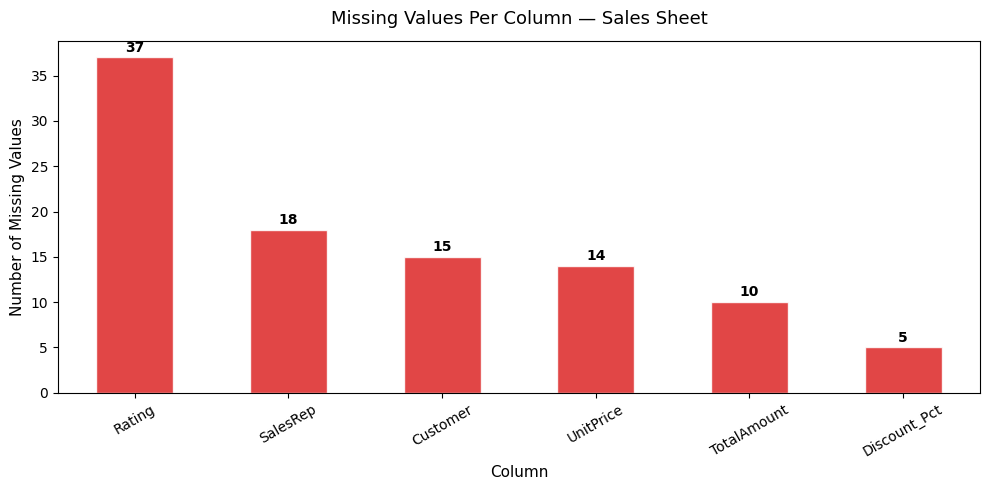

Chart saved.


In [22]:
# ─────────────────────────────────────────────────────────────────
# CELL 6.3 — Visualise Missing Values as a Bar Chart
# ─────────────────────────────────────────────────────────────────

missing_data = df_sales.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
missing_data.plot(kind='bar', ax=ax, color='#dc2626', alpha=0.85, edgecolor='white')
ax.set_title('Missing Values Per Column — Sales Sheet', fontsize=13, pad=12)
ax.set_xlabel('Column', fontsize=11)
ax.set_ylabel('Number of Missing Values', fontsize=11)
ax.tick_params(axis='x', rotation=30)

for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, str(int(h)),
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('missing_values_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

---
## 6.3 Strategies for Filling Missing Values

| Strategy | Function | Best For |
|---|---|---|
| Fill with a constant | `fillna(0)` or `fillna('Unknown')` | When you know the right replacement |
| Fill with column mean | `fillna(col.mean())` | Numeric columns without outliers |
| Fill with column median | `fillna(col.median())` | Numeric columns with outliers |
| Fill with mode | `fillna(col.mode()[0])` | Categorical/text columns |
| Forward fill | `ffill()` | Time series — carry last value forward |
| Backward fill | `bfill()` | Time series — fill from next value |
| Drop the rows | `dropna(subset=['col'])` | When % missing is very small |

In [23]:
# ─────────────────────────────────────────────────────────────────
# CELL 6.4 — Filling Missing Values in the Sales Sheet
# ─────────────────────────────────────────────────────────────────

df_sales_clean = df_sales.copy()   # always work on a copy

# --- SalesRep: fill missing with mode (most common sales rep) ---
sales_rep_mode = df_sales_clean['SalesRep'].mode()[0]
df_sales_clean['SalesRep'].fillna(sales_rep_mode, inplace=True)
print(f"SalesRep — filled with mode: '{sales_rep_mode}'")

# --- UnitPrice: fill missing with median (safer than mean — handles outliers) ---
price_median = df_sales_clean['UnitPrice'].median()
df_sales_clean['UnitPrice'].fillna(price_median, inplace=True)
print(f"UnitPrice — filled with median: {price_median:,.2f}")

# --- TotalAmount: recalculate from UnitPrice and Quantity where still missing ---
# Where TotalAmount is NaN, compute it from UnitPrice * Quantity * (1 - Discount/100)
mask_total = df_sales_clean['TotalAmount'].isnull()
df_sales_clean.loc[mask_total, 'TotalAmount'] = (
    df_sales_clean.loc[mask_total, 'UnitPrice'] *
    df_sales_clean.loc[mask_total, 'Quantity']
)
print(f"TotalAmount — recalculated {mask_total.sum()} rows from UnitPrice x Quantity")

# --- Customer: fill remaining NaN with 'Walk-in Customer' ---
df_sales_clean['Customer'].fillna('Walk-in Customer', inplace=True)
print("Customer — filled with 'Walk-in Customer'")

# --- Rating: fill with column median ---
rating_median = df_sales_clean['Rating'].median()
df_sales_clean['Rating'].fillna(rating_median, inplace=True)
print(f"Rating — filled with median: {rating_median:.1f}")

print()
print("=== Missing values after cleaning ===")
remaining = df_sales_clean.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else "No missing values remain!")

SalesRep — filled with mode: 'Chioma Eze'
UnitPrice — filled with median: 94,701.27
TotalAmount — recalculated 10 rows from UnitPrice x Quantity
Customer — filled with 'Walk-in Customer'
Rating — filled with median: 3.0

=== Missing values after cleaning ===
Discount_Pct    5
dtype: int64


In [24]:
# ─────────────────────────────────────────────────────────────────
# CELL 6.5 — Handling Missing Values in the Finance Sheet
# ─────────────────────────────────────────────────────────────────

df_fin = pd.read_excel(
    'sample.xlsx',
    sheet_name='Finance',
    na_values=['N/A','missing','--','none']
)

print("=== Finance — Missing Values ===")
fin_missing = df_fin.isnull().sum()
print(fin_missing[fin_missing > 0])
print()

df_fin_clean = df_fin.copy()

# Amount: fill with median (financial amounts often have outliers)
df_fin_clean['Amount'].fillna(df_fin_clean['Amount'].median(), inplace=True)
print(f"Amount — filled with median: {df_fin['Amount'].median():,.2f}")

# Department: fill with mode
dept_mode = df_fin_clean['Department'].mode()[0]
df_fin_clean['Department'].fillna(dept_mode, inplace=True)
print(f"Department — filled with mode: '{dept_mode}'")

# ApprovedBy: fill with 'Pending Review'
df_fin_clean['ApprovedBy'].fillna('Pending Review', inplace=True)

# Approved: fill with 'Pending'
df_fin_clean['Approved'].fillna('Pending', inplace=True)

# Quarter: fill with 'Unknown'
df_fin_clean['Quarter'].fillna('Unknown', inplace=True)

print()
remaining = df_fin_clean.isnull().sum()
print("Remaining missing values:", remaining.sum())

=== Finance — Missing Values ===
Department    14
Amount        18
ApprovedBy    40
Approved      49
Quarter       12
dtype: int64

Amount — filled with median: 262,811.52
Department — filled with mode: 'Admin'

Remaining missing values: 0


In [25]:
# ─────────────────────────────────────────────────────────────────
# CELL 6.6 — Handling Missing Values in the Health Sheet
# ─────────────────────────────────────────────────────────────────

df_hlth = pd.read_excel(
    'sample.xlsx',
    sheet_name='Health',
    na_values=['N/A','not recorded','missing','--']
)

print("=== Health — Missing Values ===")
hlth_missing = df_hlth.isnull().sum()
print(hlth_missing[hlth_missing > 0])
print()

df_hlth_clean = df_hlth.copy()

# PatientAge: outlier values of 999 are impossible — replace with NaN first
df_hlth_clean['PatientAge'] = pd.to_numeric(df_hlth_clean['PatientAge'], errors='coerce')
df_hlth_clean.loc[df_hlth_clean['PatientAge'] > 120, 'PatientAge'] = np.nan
age_median = df_hlth_clean['PatientAge'].median()
df_hlth_clean['PatientAge'].fillna(age_median, inplace=True)
print(f"PatientAge — replaced 999 outliers, filled NaN with median {age_median:.0f}")

# Gender: fill with mode
gender_mode = df_hlth_clean['Gender'].mode()[0]
df_hlth_clean['Gender'].fillna(gender_mode, inplace=True)
print(f"Gender — filled with mode: '{gender_mode}'")

# BP_Systolic: dirty values of -99 are impossible — replace with NaN, then fill median
df_hlth_clean['BP_Systolic'] = pd.to_numeric(df_hlth_clean['BP_Systolic'], errors='coerce')
df_hlth_clean.loc[df_hlth_clean['BP_Systolic'] < 0, 'BP_Systolic'] = np.nan
df_hlth_clean['BP_Systolic'].fillna(df_hlth_clean['BP_Systolic'].median(), inplace=True)
print("BP_Systolic — replaced negatives, filled NaN with median")

# BP_Diastolic: contains 'not recorded' (handled by na_values) — fill with median
df_hlth_clean['BP_Diastolic'] = pd.to_numeric(df_hlth_clean['BP_Diastolic'], errors='coerce')
df_hlth_clean['BP_Diastolic'].fillna(df_hlth_clean['BP_Diastolic'].median(), inplace=True)
print("BP_Diastolic — filled NaN with median")

# Outcome: fill with 'Under Review'
df_hlth_clean['Outcome'].fillna('Under Review', inplace=True)

# InsuranceType: fill with 'Unknown'
df_hlth_clean['InsuranceType'].fillna('Unknown', inplace=True)

print()
remaining = df_hlth_clean.isnull().sum()
print("Remaining missing values:", remaining.sum())

=== Health — Missing Values ===
PatientAge       20
Gender            9
BP_Systolic      19
BP_Diastolic     16
Outcome          41
InsuranceType    57
dtype: int64

PatientAge — replaced 999 outliers, filled NaN with median 42
Gender — filled with mode: 'Male'
BP_Systolic — replaced negatives, filled NaN with median
BP_Diastolic — filled NaN with median

Remaining missing values: 0


---
# SECTION 7: Setting and Fixing Data Types

---

## 7.1 Why Data Types Matter

When Pandas loads an Excel file, it guesses the data type of each column. It often gets this wrong:

- **Dates** may come in as `object` (plain strings) instead of `datetime64`
- **Numbers** stored as text may remain `object`
- **Boolean-like columns** ("Yes"/"No") stay as `object`

Wrong types cause wrong analysis. Always verify with `df.dtypes` and fix immediately.

### Key Type Conversion Functions

| Function | Purpose |
|---|---|
| `pd.to_datetime(col)` | Convert to datetime |
| `pd.to_numeric(col, errors='coerce')` | Convert to number (NaN on failure) |
| `col.astype('int64')` | Convert to integer |
| `col.astype('float64')` | Convert to float |
| `col.astype('str')` | Convert to string |
| `col.map({'Yes': True, 'No': False})` | Map text to bool |

In [26]:
# ─────────────────────────────────────────────────────────────────
# CELL 7.1 — Check Raw Data Types After Loading
# ─────────────────────────────────────────────────────────────────

df_check = pd.read_excel('sample.xlsx', sheet_name='Sales')

print("=== Raw Data Types — Sales Sheet ===")
print(df_check.dtypes)
print()
print("Sample OrderDate values:", df_check['OrderDate'].head(3).tolist())
print("OrderDate dtype:", df_check['OrderDate'].dtype)

=== Raw Data Types — Sales Sheet ===
OrderID          object
OrderDate        object
Customer         object
Region           object
SalesRep         object
Channel          object
Product          object
Quantity          int64
UnitPrice       float64
Discount_Pct     object
TotalAmount     float64
Status           object
Rating          float64
dtype: object

Sample OrderDate values: ['2024-01-05', '2024-01-06', '2024-01-08']
OrderDate dtype: object


In [27]:
# ─────────────────────────────────────────────────────────────────
# CELL 7.2 — parse_dates: Auto-Convert Date Columns on Load
# ─────────────────────────────────────────────────────────────────

# parse_dates=['col'] tells Pandas to convert the column to datetime
# on load — no extra step needed afterwards.

df_parsed = pd.read_excel(
    'sample.xlsx',
    sheet_name='Sales',
    parse_dates=['OrderDate'],
    na_values=['N/A', 'Unknown', 'missing']
)

print("=== With parse_dates ===")
print("OrderDate dtype:", df_parsed['OrderDate'].dtype)
print()
print("Sample date values:")
print(df_parsed['OrderDate'].head(5))

=== With parse_dates ===
OrderDate dtype: datetime64[ns]

Sample date values:
0   2024-01-05
1   2024-01-06
2   2024-01-08
3   2024-01-09
4   2024-01-11
Name: OrderDate, dtype: datetime64[ns]


In [28]:
# ─────────────────────────────────────────────────────────────────
# CELL 7.3 — Extract Date Components from Datetime Column
# ─────────────────────────────────────────────────────────────────

# Once a column is datetime, use .dt accessor to extract components

df_parsed['Year']       = df_parsed['OrderDate'].dt.year
df_parsed['Month']      = df_parsed['OrderDate'].dt.month
df_parsed['MonthName']  = df_parsed['OrderDate'].dt.month_name()
df_parsed['DayOfWeek']  = df_parsed['OrderDate'].dt.day_name()
df_parsed['Quarter']    = df_parsed['OrderDate'].dt.quarter

print("=== Date Components Extracted ===")
print(df_parsed[['OrderDate','Year','Month','MonthName','DayOfWeek','Quarter']].head(8))

=== Date Components Extracted ===
   OrderDate  Year  Month MonthName DayOfWeek  Quarter
0 2024-01-05  2024      1   January    Friday        1
1 2024-01-06  2024      1   January  Saturday        1
2 2024-01-08  2024      1   January    Monday        1
3 2024-01-09  2024      1   January   Tuesday        1
4 2024-01-11  2024      1   January  Thursday        1
5 2024-01-12  2024      1   January    Friday        1
6 2024-01-14  2024      1   January    Sunday        1
7 2024-01-15  2024      1   January    Monday        1


In [29]:
# ─────────────────────────────────────────────────────────────────
# CELL 7.4 — dtype Parameter: Force Column Types on Load
# ─────────────────────────────────────────────────────────────────

# dtype forces specific columns to specific types at load time.
# This is faster and safer than converting after loading.

df_typed = pd.read_excel(
    'sample.xlsx',
    sheet_name='Sales',
    dtype={
        'OrderID'     : str,     # keep as string (not int)
        'Quantity'    : int,     # integer quantities
        'Discount_Pct': str,     # read as string first (has dirty 'missing' entries)
    },
    na_values=['N/A', 'Unknown', 'missing']
)

print("=== Data types after dtype parameter ===")
print(df_typed.dtypes)
print()
print("OrderID sample:", df_typed['OrderID'].head(3).tolist())

=== Data types after dtype parameter ===
OrderID          object
OrderDate        object
Customer         object
Region           object
SalesRep         object
Channel          object
Product          object
Quantity          int64
UnitPrice       float64
Discount_Pct     object
TotalAmount     float64
Status           object
Rating          float64
dtype: object

OrderID sample: ['ORD1000', 'ORD1001', 'ORD1002']


In [30]:
# ─────────────────────────────────────────────────────────────────
# CELL 7.5 — Fix Discount Column: String to Numeric
# ─────────────────────────────────────────────────────────────────

# The Discount_Pct column has 'missing' strings in it.
# After loading as str and using na_values, those become NaN.
# Now convert the rest to float.

df_fix = df_sales_clean.copy()

# pd.to_numeric with errors='coerce' converts:
#   - valid numbers to float
#   - anything non-numeric to NaN
df_fix['Discount_Pct'] = pd.to_numeric(df_fix['Discount_Pct'], errors='coerce')
df_fix['Discount_Pct'].fillna(0, inplace=True)   # treat missing discount as 0%

print("Discount_Pct dtype:", df_fix['Discount_Pct'].dtype)
print()
print("Discount distribution:")
print(df_fix['Discount_Pct'].value_counts().sort_index())

Discount_Pct dtype: float64

Discount distribution:
Discount_Pct
0.00     127
5.00      62
10.00     42
15.00     47
20.00     42
Name: count, dtype: int64


In [31]:
# ─────────────────────────────────────────────────────────────────
# CELL 7.6 — Parse Dates in the Health Sheet
# ─────────────────────────────────────────────────────────────────

df_hlth_dated = pd.read_excel(
    'sample.xlsx',
    sheet_name='Health',
    parse_dates=['AdmissionDate', 'DischargeDate'],
    na_values=['not recorded', 'N/A', '--']
)

# Calculate actual length of stay from dates (verify against LengthOfStay column)
df_hlth_dated['Calc_LOS'] = (
    df_hlth_dated['DischargeDate'] - df_hlth_dated['AdmissionDate']
).dt.days

print("=== Date Parsing — Health Sheet ===")
print(df_hlth_dated[['PatientID','AdmissionDate','DischargeDate','LengthOfStay','Calc_LOS']].head(8))
print()
print("AdmissionDate dtype :", df_hlth_dated['AdmissionDate'].dtype)
print("DischargeDate dtype :", df_hlth_dated['DischargeDate'].dtype)

=== Date Parsing — Health Sheet ===
  PatientID AdmissionDate DischargeDate  LengthOfStay  Calc_LOS
0  PAT03000    2024-01-01    2024-01-04             3         3
1  PAT03001    2024-01-02    2024-01-18            16        16
2  PAT03002    2024-01-03    2024-01-17            14        14
3  PAT03003    2024-01-05    2024-01-07             2         2
4  PAT03004    2024-01-06    2024-01-09             3         3
5  PAT03005    2024-01-08    2024-02-01            24        24
6  PAT03006    2024-01-09    2024-01-21            12        12
7  PAT03007    2024-01-11    2024-01-23            12        12

AdmissionDate dtype : datetime64[ns]
DischargeDate dtype : datetime64[ns]


---
# SECTION 8: Detecting and Removing Duplicates

---

## 8.1 Why Duplicates Are Dangerous

Duplicate rows are one of the most common and damaging data quality issues in Excel files. They cause:

- **Inflated totals** — revenue, count, and sum figures are wrong
- **Skewed averages** — mean and median are biased
- **Wrong customer counts** — same person counted multiple times

Our workbook was built with intentional duplicates in every sheet: 20 in Sales, 15 in Finance, 15 in Health.

In [32]:
# ─────────────────────────────────────────────────────────────────
# CELL 8.1 — Detect Duplicates in the Sales Sheet
# ─────────────────────────────────────────────────────────────────

df_dup_check = pd.read_excel('sample.xlsx', sheet_name='Sales',
                             na_values=['N/A','Unknown','missing'])

# duplicated() returns True for the second (and later) occurrences of a duplicate row
num_dupes = df_dup_check.duplicated().sum()
print(f"Duplicate rows detected: {num_dupes}")
print()

# View the actual duplicate rows (keep=False marks ALL copies)
dupes = df_dup_check[df_dup_check.duplicated(keep=False)]
print(f"All rows involved in duplication: {len(dupes)}")
print(dupes[['OrderID','Customer','Product','TotalAmount']].head(8))

Duplicate rows detected: 20

All rows involved in duplication: 40
   OrderID     Customer   Product  TotalAmount
0  ORD1000  Customer_42    Laptop   928,208.22
1  ORD1001  Customer_11    Tablet   573,754.10
2  ORD1002  Customer_42    Laptop 1,486,388.51
3  ORD1003  Customer_57     Phone   183,086.23
4  ORD1004  Customer_77    Laptop   675,376.29
5  ORD1005  Customer_52     Phone   160,980.66
6  ORD1006   Customer_9   Monitor   109,374.79
7  ORD1007  Customer_24  Keyboard    12,907.61


In [33]:
# ─────────────────────────────────────────────────────────────────
# CELL 8.2 — Remove Duplicates
# ─────────────────────────────────────────────────────────────────

# drop_duplicates() removes duplicate rows.
# keep='first' — keep the first occurrence, remove the rest (default).
# keep='last'  — keep the last occurrence.
# keep=False   — remove ALL copies (use when you want only truly unique rows).

df_no_dupes = df_dup_check.drop_duplicates(keep='first')
df_no_dupes.reset_index(drop=True, inplace=True)

print(f"Rows BEFORE removing duplicates : {len(df_dup_check)}")
print(f"Rows AFTER  removing duplicates : {len(df_no_dupes)}")
print(f"Rows removed                    : {len(df_dup_check) - len(df_no_dupes)}")

Rows BEFORE removing duplicates : 320
Rows AFTER  removing duplicates : 300
Rows removed                    : 20


In [34]:
# ─────────────────────────────────────────────────────────────────
# CELL 8.3 — Check Duplicates on Specific Columns (Key Dedup)
# ─────────────────────────────────────────────────────────────────

# Sometimes you want to deduplicate based on a key column only.
# E.g., keep only the first record per OrderID (ignore other col differences).

dupes_by_id = df_dup_check.duplicated(subset=['OrderID']).sum()
print(f"Duplicate OrderIDs: {dupes_by_id}")

df_dedup_by_id = df_dup_check.drop_duplicates(subset=['OrderID'], keep='first')
df_dedup_by_id.reset_index(drop=True, inplace=True)
print(f"After dedup on OrderID: {len(df_dedup_by_id)} rows")

Duplicate OrderIDs: 20
After dedup on OrderID: 300 rows


---
# SECTION 9: Cleaning Wrong Formats and Dirty Data

---

## 9.1 Common Wrong Format Problems

| Problem | Example | Fix |
|---|---|---|
| Numbers stored as text | `'85,000'` | `pd.to_numeric()` |
| Dates stored as text | `'15-Jan-2025'` | `pd.to_datetime()` |
| Mixed case text | `'lagos'`, `'LAGOS'` | `.str.title()` |
| Extra whitespace | `'  Lagos '` | `.str.strip()` |
| Wrong date format | `'01/15/2025'` vs `'2025-01-15'` | `pd.to_datetime(format=...)` |
| Impossible values | Age = 999 | `.where()` + replace |

In [35]:
# ─────────────────────────────────────────────────────────────────
# CELL 9.1 — String Cleaning with .str Accessor
# ─────────────────────────────────────────────────────────────────

# The .str accessor lets you apply string operations column-wide (no loops!)

df_str_demo = df_sales_clean.copy()

# Simulate inconsistent Region values
df_str_demo['Region_dirty'] = df_str_demo['Region'].str.lower()
df_str_demo.loc[::5, 'Region_dirty'] = ' ' + df_str_demo.loc[::5, 'Region'] + '  '  # add spaces
df_str_demo.loc[1::7, 'Region_dirty'] = df_str_demo.loc[1::7, 'Region'].str.upper()

print("=== Before cleaning (sample) ===")
print(df_str_demo['Region_dirty'].unique()[:10])

# Chain .strip() then .title() to fix all in one step
df_str_demo['Region_clean'] = df_str_demo['Region_dirty'].str.strip().str.title()

print()
print("=== After .str.strip().str.title() ===")
print(df_str_demo['Region_clean'].unique())

=== Before cleaning (sample) ===
[' South  ' 'SOUTH' 'north' 'east' 'south' ' Central  ' 'west' 'NORTH'
 ' West  ' 'central']

=== After .str.strip().str.title() ===
['South' 'North' 'East' 'Central' 'West']


In [36]:
# ─────────────────────────────────────────────────────────────────
# CELL 9.2 — Fixing Impossible / Outlier Values
# ─────────────────────────────────────────────────────────────────

# Health sheet: PatientAge has values of 999 — impossible, data entry errors.
# Rule: any age > 110 is treated as a data error.

df_age = df_hlth_clean.copy()

print("=== Age Distribution Before ===")
print(df_age['PatientAge'].describe())
print()

# Convert to numeric first (handles any leftover non-numeric)
df_age['PatientAge'] = pd.to_numeric(df_age['PatientAge'], errors='coerce')

# Replace impossible ages with NaN using .where(condition_to_KEEP, replacement)
# i.e., keep values <= 110, replace everything else with NaN
df_age['PatientAge'] = df_age['PatientAge'].where(df_age['PatientAge'] <= 110, np.nan)

# Fill NaN with median
df_age['PatientAge'].fillna(df_age['PatientAge'].median(), inplace=True)

print("=== Age Distribution After ===")
print(df_age['PatientAge'].describe())

=== Age Distribution Before ===
count   265.00
mean     43.22
std      23.64
min       1.00
25%      23.00
50%      42.50
75%      64.00
max      89.00
Name: PatientAge, dtype: float64

=== Age Distribution After ===
count   265.00
mean     43.22
std      23.64
min       1.00
25%      23.00
50%      42.50
75%      64.00
max      89.00
Name: PatientAge, dtype: float64


In [37]:
# ─────────────────────────────────────────────────────────────────
# CELL 9.3 — Fixing Mixed Date Formats
# ─────────────────────────────────────────────────────────────────

# Real Excel files often have dates in multiple formats in the same column.
# pd.to_datetime() with infer_datetime_format=True or dayfirst parameter handles this.

# Simulate a column with multiple date formats
mixed_dates = pd.Series([
    '2024-01-15',     # ISO format
    '15/01/2024',     # Nigerian DD/MM/YYYY format
    '01-15-2024',     # US MM-DD-YYYY format
    '15 Jan 2024',    # Long form
    '2024/01/15',     # Slash ISO
])

print("=== Raw mixed dates ===")
print(mixed_dates.tolist())

# pd.to_datetime handles most formats automatically
converted = pd.to_datetime(mixed_dates, dayfirst=True, errors='coerce')
print()
print("=== After pd.to_datetime(dayfirst=True) ===")
print(converted.tolist())

=== Raw mixed dates ===
['2024-01-15', '15/01/2024', '01-15-2024', '15 Jan 2024', '2024/01/15']

=== After pd.to_datetime(dayfirst=True) ===
[Timestamp('2024-01-15 00:00:00'), NaT, NaT, NaT, NaT]


In [38]:
# ─────────────────────────────────────────────────────────────────
# CELL 9.4 — Standardising Categorical Text Values
# ─────────────────────────────────────────────────────────────────

# .replace() maps old values to new values — useful for standardising categories

df_status_fix = df_sales_clean.copy()

# Standardise Status column (ensure consistent capitalisation and naming)
status_map = {
    'delivered'  : 'Delivered',
    'DELIVERED'  : 'Delivered',
    'pending'    : 'Pending',
    'PENDING'    : 'Pending',
    'returned'   : 'Returned',
    'cancelled'  : 'Cancelled',
    'CANCELLED'  : 'Cancelled',
}
df_status_fix['Status'] = df_status_fix['Status'].replace(status_map)

# Also use .str.title() as a catch-all
df_status_fix['Status'] = df_status_fix['Status'].str.strip().str.title()

print("=== Standardised Status Values ===")
print(df_status_fix['Status'].value_counts())

=== Standardised Status Values ===
Status
Delivered    166
Returned      58
Cancelled     55
Pending       41
Name: count, dtype: int64


In [39]:
# ─────────────────────────────────────────────────────────────────
# CELL 9.5 — Adding Derived Columns After Cleaning
# ─────────────────────────────────────────────────────────────────

# Once data is clean, add feature columns that drive analysis

df_final_sales = df_sales_clean.copy()
df_final_sales['OrderDate'] = pd.to_datetime(df_final_sales['OrderDate'])
df_final_sales['Discount_Pct'] = pd.to_numeric(df_final_sales['Discount_Pct'], errors='coerce').fillna(0)

# Calculate revenue BEFORE discount
df_final_sales['GrossRevenue'] = df_final_sales['UnitPrice'] * df_final_sales['Quantity']

# Discount Amount
df_final_sales['DiscountAmount'] = df_final_sales['GrossRevenue'] * (df_final_sales['Discount_Pct'] / 100)

# Recalculate clean TotalAmount
df_final_sales['TotalAmount_Clean'] = df_final_sales['GrossRevenue'] - df_final_sales['DiscountAmount']

# Month label
df_final_sales['YearMonth'] = df_final_sales['OrderDate'].dt.to_period('M').astype(str)

# High value flag
df_final_sales['IsHighValue'] = df_final_sales['TotalAmount_Clean'] > df_final_sales['TotalAmount_Clean'].median()

print("=== Derived Columns Added ===")
print(df_final_sales[['OrderID','GrossRevenue','DiscountAmount','TotalAmount_Clean','YearMonth','IsHighValue']].head(8).round(2))

=== Derived Columns Added ===
   OrderID  GrossRevenue  DiscountAmount  TotalAmount_Clean YearMonth  IsHighValue
0  ORD1000    928,208.22            0.00         928,208.22   2024-01         True
1  ORD1001    637,504.55       63,750.46         573,754.10   2024-01         True
2  ORD1002    378,805.08       18,940.25         359,864.83   2024-01         True
3  ORD1003    228,857.79       45,771.56         183,086.23   2024-01        False
4  ORD1004    794,560.34      119,184.05         675,376.29   2024-01         True
5  ORD1005    160,980.66            0.00         160,980.66   2024-01        False
6  ORD1006    109,374.79            0.00         109,374.79   2024-01        False
7  ORD1007     15,185.42        2,277.81          12,907.61   2024-01        False


---
# SECTION 10: Analysis After Clean Loading

---

## 10.1 GroupBy Analysis

Now that the data is clean, we can run meaningful analysis.

In [40]:
# ─────────────────────────────────────────────────────────────────
# CELL 10.1 — Sales Analysis by Region and Product
# ─────────────────────────────────────────────────────────────────

df_a = df_final_sales.drop_duplicates(subset=['OrderID'], keep='first').copy()

# Revenue by Region
print("=== Total Revenue by Region ===")
region_rev = df_a.groupby('Region')['TotalAmount_Clean'].sum().sort_values(ascending=False)
for region, rev in region_rev.items():
    print(f"  {region:<10}  N{rev:>15,.0f}")
print()

# Revenue by Product
print("=== Revenue by Product ===")
product_rev = df_a.groupby('Product')['TotalAmount_Clean'].agg(
    Orders  = 'count',
    Revenue = 'sum',
    Avg_Rev = 'mean'
).round(0).sort_values('Revenue', ascending=False)
print(product_rev)

=== Total Revenue by Region ===
  North       N     20,329,771
  West        N     17,213,922
  Central     N     15,629,766
  East        N     14,981,190
  South       N     13,790,083

=== Revenue by Product ===
          Orders       Revenue    Avg_Rev
Product                                  
Laptop        38 27,967,752.00 735,993.00
Tablet        42 16,057,456.00 382,320.00
Monitor       39 12,397,178.00 317,876.00
Printer       32  9,067,259.00 283,352.00
Phone         41  8,051,846.00 196,386.00
Router        40  4,094,860.00 102,372.00
Headset       39  2,884,075.00  73,951.00
Keyboard      29  1,424,306.00  49,114.00


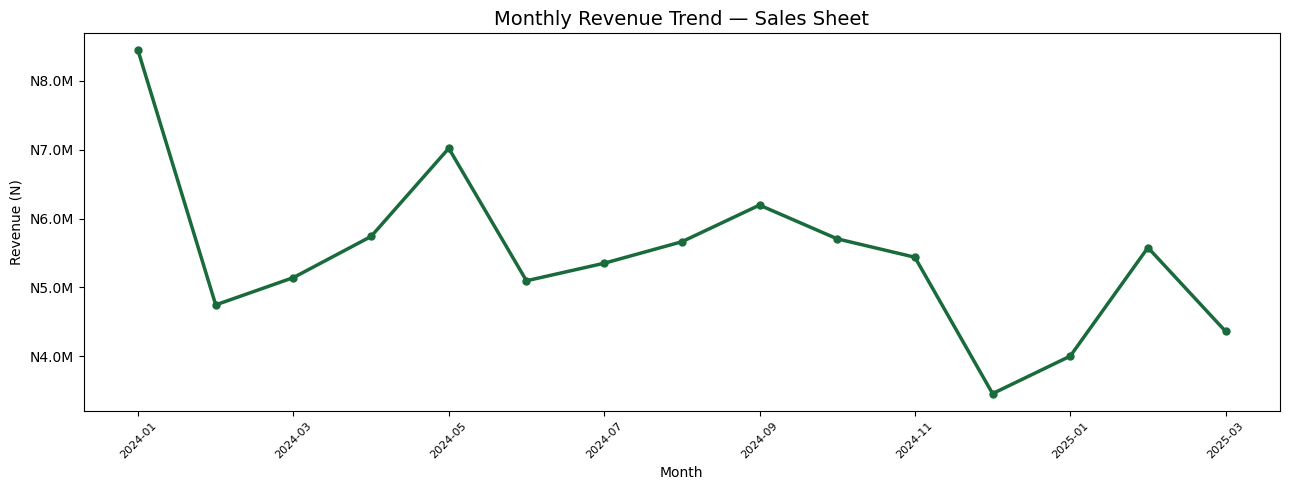

In [41]:
# ─────────────────────────────────────────────────────────────────
# CELL 10.2 — Monthly Revenue Trend
# ─────────────────────────────────────────────────────────────────

monthly = df_a.groupby('YearMonth')['TotalAmount_Clean'].sum()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(range(len(monthly)), monthly.values,
        color='#1a6b3c', linewidth=2.5, marker='o', markersize=5)

ax.set_title('Monthly Revenue Trend — Sales Sheet', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (N)')
ax.set_xticks(range(0, len(monthly), 2))
ax.set_xticklabels(monthly.index.tolist()[::2], rotation=45, fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

=== Department Spend Analysis ===
            Transactions   Total_Spend  Avg_Spend
Department                                       
Admin                 46 11,879,091.00 258,241.00
HR                    28  8,019,711.00 286,418.00
Legal                 27  7,815,477.00 289,462.00
IT                    34  7,414,831.00 218,083.00
Marketing             26  6,482,455.00 249,325.00
Finance               24  6,344,046.00 264,335.00
Operations            15  4,233,876.00 282,258.00



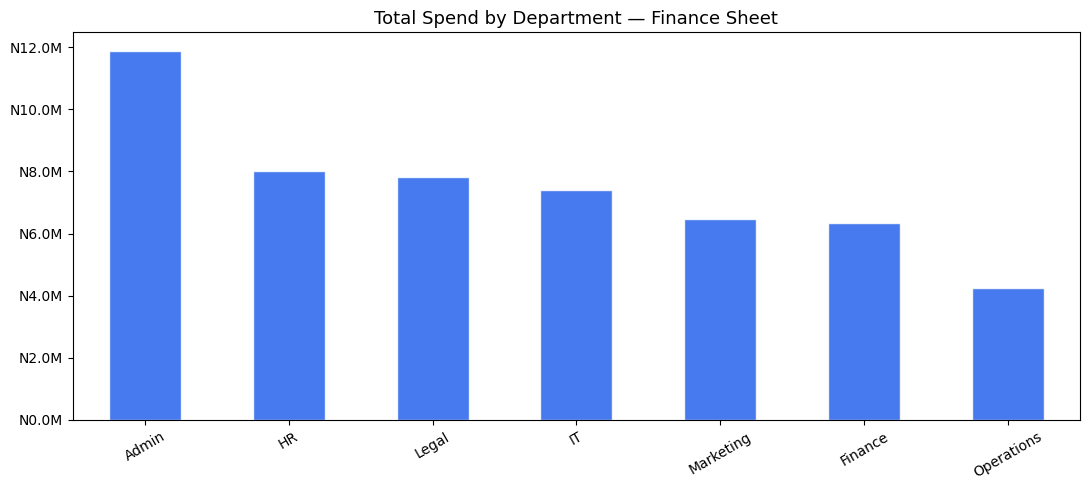

In [42]:
# ─────────────────────────────────────────────────────────────────
# CELL 10.3 — Finance Sheet: Department Spend Analysis
# ─────────────────────────────────────────────────────────────────

df_fin2 = df_fin_clean.drop_duplicates(keep='first').copy()
df_fin2['Amount'] = pd.to_numeric(df_fin2['Amount'], errors='coerce').fillna(0)

dept_spend = df_fin2.groupby('Department').agg(
    Transactions = ('TransactionID', 'count'),
    Total_Spend  = ('Amount', 'sum'),
    Avg_Spend    = ('Amount', 'mean')
).round(0).sort_values('Total_Spend', ascending=False)

print("=== Department Spend Analysis ===")
print(dept_spend)
print()

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
dept_spend['Total_Spend'].plot(kind='bar', ax=ax, color='#2563eb', alpha=0.85, edgecolor='white')
ax.set_title('Total Spend by Department — Finance Sheet', fontsize=13)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'N{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('dept_spend.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# ─────────────────────────────────────────────────────────────────
# CELL 10.4 — Health Sheet: Diagnosis and Outcome Analysis
# ─────────────────────────────────────────────────────────────────

df_hlth2 = df_hlth_clean.drop_duplicates(keep='first').copy()

# Diagnosis distribution
print("=== Diagnosis Distribution ===")
print(df_hlth2['Diagnosis'].value_counts())
print()

# Average length of stay by diagnosis
print("=== Avg Length of Stay by Diagnosis ===")
los_by_diag = df_hlth2.groupby('Diagnosis')['LengthOfStay'].agg(
    Patients     = 'count',
    Avg_LOS_Days = 'mean',
    Max_LOS_Days = 'max'
).round(1).sort_values('Avg_LOS_Days', ascending=False)
print(los_by_diag)

=== Diagnosis Distribution ===
Diagnosis
Diabetes        45
Anaemia         34
Hypertension    34
COVID-19        31
Pneumonia       31
Typhoid         30
Fracture        23
Malaria         22
Name: count, dtype: int64

=== Avg Length of Stay by Diagnosis ===
              Patients  Avg_LOS_Days  Max_LOS_Days
Diagnosis                                         
Pneumonia           31         19.00            29
Hypertension        34         16.40            29
Anaemia             34         14.80            28
Diabetes            45         14.60            29
Fracture            23         14.40            29
Malaria             22         13.80            29
Typhoid             30         13.20            27
COVID-19            31         12.70            29


In [44]:
# ─────────────────────────────────────────────────────────────────
# CELL 10.5 — Pivot Table: Sales by Region and Product
# ─────────────────────────────────────────────────────────────────

pivot = pd.pivot_table(
    df_a,
    values  = 'TotalAmount_Clean',
    index   = 'Region',
    columns = 'Product',
    aggfunc = 'sum',
    fill_value = 0
).round(0)

print("=== Pivot Table: Revenue by Region x Product ===")
print(pivot)

=== Pivot Table: Revenue by Region x Product ===
Product      Headset   Keyboard       Laptop      Monitor        Phone      Printer       Router       Tablet
Region                                                                                                       
Central   733,229.00 605,615.00 4,037,078.00 2,139,494.00 1,480,905.00 1,748,321.00   481,808.00 4,403,316.00
East      555,067.00 386,293.00 4,947,222.00 1,999,474.00 1,735,213.00 1,360,064.00   642,084.00 3,355,772.00
North   1,017,444.00  74,669.00 5,152,219.00 5,282,088.00 1,460,663.00 2,777,066.00 1,377,434.00 3,188,187.00
South     276,579.00 163,482.00 5,455,799.00 1,620,438.00 2,239,952.00 1,134,155.00   885,817.00 2,013,860.00
West      301,756.00 194,246.00 8,375,434.00 1,355,684.00 1,135,113.00 2,047,652.00   707,717.00 3,096,321.00


In [45]:
# ─────────────────────────────────────────────────────────────────
# CELL 10.6 — Inventory Analysis: Low Stock Alert
# ─────────────────────────────────────────────────────────────────

df_inv2 = pd.read_excel(
    'sample.xlsx',
    sheet_name='Inventory',
    skiprows=3
)

# Items below reorder level (need restocking)
df_inv2['BelowReorder'] = df_inv2['StockQty'] < df_inv2['ReorderLevel']
df_inv2['Profit_Margin'] = df_inv2['SellingPrice'] - df_inv2['CostPrice']

low_stock = df_inv2[df_inv2['BelowReorder']].sort_values('StockQty')
print(f"=== Low Stock Items: {len(low_stock)} out of {len(df_inv2)} ===")
print(low_stock[['ItemCode','ItemName','StockQty','ReorderLevel','Supplier']].head(10))

=== Low Stock Items: 6 out of 100 ===
   ItemCode    ItemName  StockQty  ReorderLevel          Supplier
66  ITM5066     SSD 1TB        18            26      Slot Systems
94  ITM5094  Power Bank        22            38        Zinox Tech
55  ITM5055         UPS        29            41            Mikano
43  ITM5043  HDMI Cable        37            41      Slot Systems
74  ITM5074     SSD 1TB        38            45  Interswitch Tech
11  ITM5011     USB Hub        40            44    Fouani Nigeria


---
# SECTION 11: Reading Large Excel Files Efficiently

---

## 11.1 Performance Best Practices

Large Excel files (10,000+ rows, many columns) can be slow or memory-intensive to load. These techniques keep things fast:

| Technique | How | Benefit |
|---|---|---|
| Load only needed columns | `usecols=[...]` | Reduces memory significantly |
| Load only needed rows | `nrows=n` | Fast for sampling during development |
| Read specific sheets | `sheet_name='Sheet1'` | Avoid loading unused sheets |
| Use `dtype` correctly | `dtype={'col': 'int32'}` | Reduces memory per column |
| Use `chunksize` (CSV) | Not available for Excel | Excel must be fully loaded |

In [46]:
# ─────────────────────────────────────────────────────────────────
# CELL 11.1 — Efficient Loading: Only What You Need
# ─────────────────────────────────────────────────────────────────

import time

# Full load
t0 = time.time()
df_full = pd.read_excel('sample.xlsx', sheet_name='Sales')
t_full = time.time() - t0

# Efficient load: only 6 columns, parse dates on load
t0 = time.time()
df_efficient = pd.read_excel(
    'sample.xlsx',
    sheet_name='Sales',
    usecols=['OrderID', 'OrderDate', 'Product', 'Region', 'TotalAmount', 'Status'],
    parse_dates=['OrderDate'],
    na_values=['N/A', 'Unknown', 'missing']
)
t_efficient = time.time() - t0

print(f"Full load    : {df_full.shape}    in {t_full:.3f}s   | Memory: {df_full.memory_usage(deep=True).sum()/1024:.1f} KB")
print(f"Efficient    : {df_efficient.shape}  in {t_efficient:.3f}s   | Memory: {df_efficient.memory_usage(deep=True).sum()/1024:.1f} KB")
print()
print(df_efficient.head(4))

Full load    : (320, 13)    in 0.255s   | Memory: 163.9 KB
Efficient    : (320, 6)  in 0.188s   | Memory: 74.8 KB

   OrderID  OrderDate Region Product  TotalAmount     Status
0  ORD1000 2024-01-05  South  Laptop   928,208.22  Delivered
1  ORD1001 2024-01-06  South  Tablet   573,754.10  Delivered
2  ORD1002 2024-01-08  North  Laptop 1,486,388.51   Returned
3  ORD1003 2024-01-09   East   Phone   183,086.23  Delivered


In [47]:
# ─────────────────────────────────────────────────────────────────
# CELL 11.2 — Using ExcelFile for Multiple Sheet Reads
# ─────────────────────────────────────────────────────────────────

# If you need to read multiple sheets from the same file,
# ExcelFile opens the file ONCE and reads from it multiple times.
# This is faster than calling pd.read_excel() separately for each sheet.

# Good: open once, parse multiple times
with pd.ExcelFile('sample.xlsx') as xf:
    df_s = xf.parse('Sales',   na_values=['N/A','Unknown','missing'],
                    parse_dates=['OrderDate'])
    df_f = xf.parse('Finance', na_values=['N/A','missing','--'],
                    parse_dates=['TransactionDate'])
    df_h = xf.parse('Health',  na_values=['not recorded','N/A'],
                    parse_dates=['AdmissionDate','DischargeDate'])

print("Loaded all sheets efficiently with ExcelFile context manager:")
print(f"  Sales   : {df_s.shape}")
print(f"  Finance : {df_f.shape}")
print(f"  Health  : {df_h.shape}")

Loaded all sheets efficiently with ExcelFile context manager:
  Sales   : (320, 13)
  Finance : (215, 10)
  Health  : (265, 13)


---
# SECTION 12: Practical Teaching Exercises

---

These exercises consolidate everything covered in this notebook. Complete each one independently before checking the solution cell below it.

---

### Exercise 1
Load only the **Finance** sheet. Show only the `TransactionDate`, `Department`, `ExpenseType`, and `Amount` columns. Treat `'N/A'` and `'missing'` as null values. Show the first 10 rows.

In [48]:
# ─────────────────────────────────────────────────────────────────
# EXERCISE 1 — Solution
# ─────────────────────────────────────────────────────────────────

ex1 = pd.read_excel(
    'sample.xlsx',
    sheet_name='Finance',
    usecols=['TransactionDate','Department','ExpenseType','Amount'],
    na_values=['N/A','missing','--'],
    parse_dates=['TransactionDate']
)

print(f"Shape: {ex1.shape}")
print(ex1.head(10))

Shape: (215, 4)
  TransactionDate  Department  ExpenseType     Amount
0      2024-01-01   Marketing     Supplies 318,717.72
1      2024-01-02         NaN     Supplies 181,407.54
2      2024-01-04          HR     Supplies 314,868.73
3      2024-01-06   Marketing       Salary 126,671.82
4      2024-01-08          IT  Maintenance 374,741.73
5      2024-01-10       Admin  Consultancy  49,350.85
6      2024-01-12       Admin       Salary 412,316.52
7      2024-01-13       Admin     Training  91,746.31
8      2024-01-15         NaN  Maintenance 242,631.24
9      2024-01-17  Operations       Travel        NaN


---
### Exercise 2
Load the **Inventory** sheet. The first 3 rows are title rows — handle them. After loading, add a column called `ProfitMargin` that equals `SellingPrice - CostPrice`. Show items where `ProfitMargin > 10000`.

In [49]:
# ─────────────────────────────────────────────────────────────────
# EXERCISE 2 — Solution
# ─────────────────────────────────────────────────────────────────

ex2 = pd.read_excel('sample.xlsx', sheet_name='Inventory', skiprows=3)

ex2['ProfitMargin'] = ex2['SellingPrice'] - ex2['CostPrice']

high_margin = ex2[ex2['ProfitMargin'] > 10000].sort_values('ProfitMargin', ascending=False)

print(f"Items with ProfitMargin > N10,000: {len(high_margin)}")
print(high_margin[['ItemCode','ItemName','CostPrice','SellingPrice','ProfitMargin']].head(10))

Items with ProfitMargin > N10,000: 62
   ItemCode         ItemName  CostPrice  SellingPrice  ProfitMargin
78  ITM5078  Ethernet Switch  30,670.05    241,291.44    210,621.39
59  ITM5059              UPS   5,854.50    189,370.74    183,516.24
98  ITM5098          USB Hub  76,625.34    243,602.28    166,976.94
96  ITM5096       HDMI Cable  54,858.54    220,707.39    165,848.85
39  ITM5039           Webcam  70,473.77    222,953.38    152,479.61
83  ITM5083          SSD 1TB  69,784.68    220,980.59    151,195.91
14  ITM5014  Ethernet Switch  27,969.68    166,818.41    138,848.73
12  ITM5012       Power Bank  22,239.35    154,714.72    132,475.37
16  ITM5016  Ethernet Switch  59,518.42    189,340.15    129,821.73
29  ITM5029         RAM 16GB  18,227.64    137,844.01    119,616.37


---
### Exercise 3
Load **all sheets** at once. Print the shape of each sheet. Then combine all sheets into one DataFrame and add a `source_sheet` column to track which sheet each row came from.

In [50]:
# ─────────────────────────────────────────────────────────────────
# EXERCISE 3 — Solution
# ─────────────────────────────────────────────────────────────────

all_data = pd.read_excel('sample.xlsx', sheet_name=None,
                         na_values=['N/A','Unknown','missing','not recorded','--'])

print("=== Shape of Each Sheet ===")
for name, dfs in all_data.items():
    print(f"  {name:<12}: {dfs.shape}")
print()

# Tag each sheet and combine
tagged = []
for name, dfs in all_data.items():
    dfs_copy = dfs.copy()
    dfs_copy['source_sheet'] = name
    tagged.append(dfs_copy)

combined_all = pd.concat(tagged, ignore_index=True)
print(f"Combined shape: {combined_all.shape}")
print()
print("source_sheet distribution:")
print(combined_all['source_sheet'].value_counts())

=== Shape of Each Sheet ===
  Sales       : (320, 13)
  Finance     : (215, 10)
  Health      : (265, 13)
  Inventory   : (103, 10)

Combined shape: (903, 47)

source_sheet distribution:
source_sheet
Sales        320
Health       265
Finance      215
Inventory    103
Name: count, dtype: int64


---
### Exercise 4
Load the **Sales** sheet. Remove all duplicate rows. Fill all missing values appropriately (numeric: median, text: mode). Confirm no missing values remain.

In [51]:
# ─────────────────────────────────────────────────────────────────
# EXERCISE 4 — Solution
# ─────────────────────────────────────────────────────────────────

ex4 = pd.read_excel('sample.xlsx', sheet_name='Sales',
                    na_values=['N/A','Unknown','missing'],
                    parse_dates=['OrderDate'])

print(f"Before dedup  : {len(ex4)} rows")
ex4.drop_duplicates(inplace=True)
ex4.reset_index(drop=True, inplace=True)
print(f"After dedup   : {len(ex4)} rows")
print()

# Fill missing values
for col in ex4.select_dtypes(include='number').columns:
    ex4[col].fillna(ex4[col].median(), inplace=True)

for col in ex4.select_dtypes(include='object').columns:
    if ex4[col].isnull().sum() > 0:
        ex4[col].fillna(ex4[col].mode()[0], inplace=True)

remaining = ex4.isnull().sum().sum()
print(f"Remaining missing values: {remaining}")
print("Status: CLEAN!" if remaining == 0 else "Warning: some NaN remain")
print()
print(ex4.head(5))

Before dedup  : 320 rows
After dedup   : 300 rows

Remaining missing values: 0
Status: CLEAN!

   OrderID  OrderDate     Customer Region       SalesRep      Channel Product  Quantity  UnitPrice  Discount_Pct  \
0  ORD1000 2024-01-05  Customer_42  South  Tunde Adeyemi  Phone Order  Laptop         3 309,402.74          0.00   
1  ORD1001 2024-01-06  Customer_11  South  Tunde Adeyemi      Partner  Tablet         5 127,500.91         10.00   
2  ORD1002 2024-01-08  Customer_42  North     Ngozi Dike      Walk-in  Laptop         4  94,701.27          5.00   
3  ORD1003 2024-01-09  Customer_57   East    Aisha Garba       Online   Phone         3  76,285.93         20.00   
4  ORD1004 2024-01-11  Customer_77  South     Ngozi Dike      Walk-in  Laptop         2 397,280.17         15.00   

   TotalAmount     Status  Rating  
0   928,208.22  Delivered    5.00  
1   573,754.10  Delivered    2.00  
2 1,486,388.51   Returned    1.00  
3   183,086.23  Delivered    1.00  
4   675,376.29   Returned   

---
### Exercise 5
Load the **Health** sheet. Parse `AdmissionDate` and `DischargeDate` as dates. Calculate `LengthOfStay_Calc` from the two date columns. Group by `Diagnosis` and show average `LengthOfStay_Calc` per diagnosis.

In [52]:
# ─────────────────────────────────────────────────────────────────
# EXERCISE 5 — Solution
# ─────────────────────────────────────────────────────────────────

ex5 = pd.read_excel('sample.xlsx', sheet_name='Health',
                    parse_dates=['AdmissionDate','DischargeDate'],
                    na_values=['not recorded','N/A','--','missing'])

ex5['LengthOfStay_Calc'] = (ex5['DischargeDate'] - ex5['AdmissionDate']).dt.days

# Remove duplicates
ex5.drop_duplicates(inplace=True)

# Fill missing LOS
ex5['LengthOfStay_Calc'].fillna(ex5['LengthOfStay_Calc'].median(), inplace=True)

avg_los = ex5.groupby('Diagnosis')['LengthOfStay_Calc'].agg(
    Patients = 'count',
    Avg_Days = 'mean',
    Max_Days = 'max'
).round(1).sort_values('Avg_Days', ascending=False)

print("=== Average Length of Stay by Diagnosis ===")
print(avg_los)

=== Average Length of Stay by Diagnosis ===
              Patients  Avg_Days  Max_Days
Diagnosis                                 
Pneumonia           31     19.00        29
Hypertension        34     16.40        29
Anaemia             34     14.80        28
Diabetes            45     14.60        29
Fracture            23     14.40        29
Malaria             22     13.80        29
Typhoid             30     13.20        27
COVID-19            31     12.70        29


---
# SECTION 13: Summary and Cheat Sheet

---

## `pd.read_excel()` — Complete Parameter Reference

```python
pd.read_excel(
    io,                         # File path: 'data.xlsx'
    sheet_name=0,               # 0=first, 'Name', ['A','B'], None=all
    header=0,                   # Row number for column names (0-indexed)
    index_col=None,             # Column to use as row index
    usecols=None,               # ['col1','col2'] or 'A:D' or [0,1,2]
    dtype=None,                 # {'col': int, 'col2': str}
    na_values=['N/A','missing'],# Extra strings to treat as NaN
    skiprows=None,              # Skip first n rows, or list of row numbers
    nrows=None,                 # Max rows to read (excludes header)
    parse_dates=['date_col'],   # Auto-convert to datetime
    engine='openpyxl',          # openpyxl for .xlsx; xlrd for .xls
)
```

---

## Key Data Cleaning Commands

```python
# Missing values
df.isnull().sum()                          # Count NaN per column
df['col'].fillna(df['col'].median())       # Fill with median
df['col'].fillna(df['col'].mode()[0])      # Fill with mode (most frequent)
df['col'].ffill()                          # Forward fill (time series)
df.dropna(subset=['col'])                  # Drop rows where 'col' is NaN

# Duplicates
df.duplicated().sum()                      # Count duplicate rows
df.drop_duplicates(keep='first')           # Remove duplicates

# Data types
pd.to_datetime(df['col'])                  # Convert to datetime
pd.to_numeric(df['col'], errors='coerce')  # Convert to number
df['col'].astype('float64')                # Force a type

# String cleaning
df['col'].str.strip().str.title()          # Remove whitespace, title case
df['col'].str.lower()                      # Lowercase
df['col'].str.replace('old','new')         # Replace substring
df['col'].str.contains('pattern')         # Partial match (boolean)

# Outlier cleaning
df['col'] = df['col'].where(df['col'] <= max_valid, np.nan)

# Date components
df['col'].dt.year | .month | .day_name() | .quarter
```

---

## What to Do Every Time You Load an Excel File

1. `df.info()` — check column types and missing counts
2. `df.isnull().sum()` — quantify every missing value
3. `df.duplicated().sum()` — detect duplicates
4. `df.describe()` — spot outliers (impossible min/max)
5. `df.head()` and `df.sample(5)` — eyeball the data

Clean in this order:
1. Remove duplicates
2. Fix data types (especially dates)
3. Handle missing values
4. Fix dirty/impossible values
5. Standardise text (strip, title case, replace)
6. Add derived columns

---

> *"The goal of data cleaning is not perfection — it is fitness for purpose."*  
> Every row you clean brings your analysis closer to the truth.  
> — **Prodigy Training Hub**

---